# Cryptocurrency Funding Rates and Price Prediction: An Empirical Study

## Introduction

Cryptocurrency perpetual futures contracts have become a cornerstone of the digital asset trading ecosystem, offering traders leveraged exposure without the complexity of managing contract expirations. At the heart of these instruments is the funding rate mechanism - a periodic payment between long and short contract holders that helps tether perpetual contract prices to their underlying spot markets.

### Understanding Funding Rates

Funding rates serve as a balancing mechanism in perpetual futures markets:

- **Positive funding rates** occur when perpetual prices trade at a premium to spot, causing long position holders to pay shorts
- **Negative funding rates** occur when perpetual prices trade at a discount, resulting in short position holders paying longs
- **Funding payments** typically occur every 8 hours on major exchanges like Binance

Theoretically, funding rates offer valuable insights into market sentiment and positioning:

1. **Market sentiment indicator**: Sustained positive rates may indicate bullish sentiment, while negative rates suggest bearish sentiment
2. **Potential predictor**: Extreme funding rates might signal overleveraged positions and potential market reversals
3. **Arbitrage signal**: Divergences between funding and price action may present cross-market opportunities

### Research Objectives

This study examines the relationship between cryptocurrency funding rates and subsequent price movements to determine if they contain exploitable predictive signals. Specifically, I aim to answer:

1. Do funding rates provide statistically significant predictive power for future returns?
2. Can machine learning models effectively capture relationships between funding rates and price movements?
3. Do these relationships change across different market cycles (bull vs. bear markets)?
4. Could trading strategies based on funding rate signals generate alpha?

### Dataset and Methodology

My analysis utilises historical data from Binance for ten major cryptocurrencies spanning April 2021 to April 2025, covering:

- Hourly price data (OHLC) for spot markets
- 8-hour funding rate data for perpetual futures
- Complete market cycles including the 2021 bull market, 2022-2023 bear market, and 2024-2025 bull market

The methodology employs three modeling approaches with increasing complexity:
- Linear regression (baseline)
- Random Forest (non-linear)
- Gradient Boosting (ensemble)

Each model is evaluated using time-series cross-validation, feature importance analysis, and backtested trading strategies to provide a comprehensive assessment of funding rates as potential predictive signals.

In [1]:
from dotenv import load_dotenv
import os
from binance import Client
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

load_dotenv()
api_key = os.getenv("BINANCE_API_KEY")
api_secret = os.getenv("BINANCE_SECRET_KEY")
client = Client(api_key, api_secret)

spot_symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'DOGEUSDT', 'BNBUSDT', 
               'LINKUSDT', 'AAVEUSDT', 'UNIUSDT', 'ADAUSDT', 'DOTUSDT']
perp_symbols = [s.replace('USDT', 'USD').upper() + '_PERP' for s in spot_symbols]


print(f"Spot symbols: {spot_symbols}")
print(f"Perpetual symbols: {perp_symbols}")

Spot symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'DOGEUSDT', 'BNBUSDT', 'LINKUSDT', 'AAVEUSDT', 'UNIUSDT', 'ADAUSDT', 'DOTUSDT']
Perpetual symbols: ['BTCUSD_PERP', 'ETHUSD_PERP', 'SOLUSD_PERP', 'DOGEUSD_PERP', 'BNBUSD_PERP', 'LINKUSD_PERP', 'AAVEUSD_PERP', 'UNIUSD_PERP', 'ADAUSD_PERP', 'DOTUSD_PERP']


In [2]:
class DataCollector:
    def __init__(self, api_key=None, api_secret=None, start_date=None, end_date=None):
        if api_key is None or api_secret is None:
            load_dotenv()
            api_key = os.getenv("BINANCE_API_KEY")
            api_secret = os.getenv("BINANCE_SECRET_KEY")
            
        self.client = Client(api_key, api_secret)
        

        if end_date is None:
            self.end_date = datetime.now()
        else:
            self.end_date = end_date
            
        if start_date is None:
            self.start_date = self.end_date - timedelta(days=48*30)
        else:
            self.start_date = start_date
            
        self.spot_symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'DOGEUSDT', 'BNBUSDT', 
                            'LINKUSDT', 'AAVEUSDT', 'UNIUSDT', 'ADAUSDT', 'DOTUSDT']
        self.perp_symbols = [s.replace('USDT', 'USD').upper() + '_PERP' for s in self.spot_symbols]
        
        self.spot_data = {}
        self.funding_data = {}
        
    def fetch_historical_price_data(self, symbol, start_date=None, end_date=None):
        """
        Fetch historical spot price data for a given symbol.
        """
        if start_date is None:
            start_date = self.start_date
        if end_date is None:
            end_date = self.end_date
            
        print(f"Fetching historical data for {symbol}...")
        
        start_timestamp = int(start_date.timestamp() * 1000)
        end_timestamp = int(end_date.timestamp() * 1000)
        
        historical = self.client.get_historical_klines(
            symbol, 
            self.client.KLINE_INTERVAL_1HOUR,
            start_timestamp,
            end_timestamp
        )
        
        columns = ['open_time', 'open', 'high', 'low', 'close', 'volume',
                  'close_time', 'quote_asset_volume', 'number_of_trades',
                  'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore']
        
        data = pd.DataFrame(historical, columns=columns)
        
        # Convert timestamp columns to datetime
        data['open_time'] = pd.to_datetime(data['open_time'], unit='ms')
        data['close_time'] = pd.to_datetime(data['close_time'], unit='ms')
        
        # Convert numeric columns to float
        numeric_columns = ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
                         'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
        data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric)
        
        return data
    
    def fetch_funding_rates(self, symbol, start_date=None, end_date=None):
        """
        Fetch funding rates for a perpetual futures contract.
        """
        if start_date is None:
            start_date = self.start_date
        if end_date is None:
            end_date = self.end_date
            
        print(f"Fetching funding rates for {symbol}...")
        
        funding_rates = []
        start_timestamp = int(start_date.timestamp() * 1000) - int(timedelta(hours=8).total_seconds() * 1000)
        end_timestamp = int(end_date.timestamp() * 1000)
        
        # Fetch data in batches due to API limitations
        while start_timestamp < end_timestamp:
            rates = self.client.futures_coin_funding_rate(
                symbol=symbol, 
                startTime=start_timestamp,
                limit=1000
            )
            
            if not rates:
                break
                
            funding_rates.extend(rates)
            last_rate_timestamp = rates[-1]['fundingTime']
            start_timestamp = last_rate_timestamp + 1
            
        funding_rate_df = pd.DataFrame(funding_rates)
        
        if not funding_rate_df.empty:
            funding_rate_df['fundingTime'] = pd.to_datetime(funding_rate_df['fundingTime'], unit='ms')
            funding_rate_df['fundingRate'] = pd.to_numeric(funding_rate_df['fundingRate'])
            
        return funding_rate_df
    
    def collect_all_data(self):
        """
        Collect spot price and funding rate data for all symbols.
        """
        # Collect spot price data
        for symbol in self.spot_symbols:
            self.spot_data[symbol] = self.fetch_historical_price_data(symbol)
            
        # Collect funding rate data
        for symbol in self.perp_symbols:
            self.funding_data[symbol] = self.fetch_funding_rates(symbol)
            
        return self.spot_data, self.funding_data
    
    def get_coin_data(self, symbol):
        """
        Get spot and funding data for a specific coin.
        """
        perp_symbol = symbol.replace('USDT', 'USD').upper() + '_PERP'
        
        if symbol not in self.spot_data:
            self.spot_data[symbol] = self.fetch_historical_spot_data(symbol)
            
        if perp_symbol not in self.funding_data:
            self.funding_data[perp_symbol] = self.fetch_funding_rates(perp_symbol)
            
        return self.spot_data[symbol], self.funding_data[perp_symbol]
    
    def save_data(self, directory='./data'):
        """
        Save collected data to CSV files.
        """
        # create directory
        os.makedirs(directory, exist_ok=True)
        
        # save data
        for symbol, data in self.spot_data.items():
            filename = f"{directory}/{symbol.lower()}_price_data.csv"
            data.to_csv(filename, index=False)
            print(f"Saved {filename}")
            
        # save funding rate data
        for symbol, data in self.funding_data.items():
            filename = f"{directory}/{symbol.lower()}_funding_data.csv"
            data.to_csv(filename, index=False)
            print(f"Saved {filename}")
    
    def load_data(self, directory='./data'):
        """
        Load data from saved CSV files.
        """
        self.spot_data = {}
        self.funding_data = {}
        
        # load data
        for symbol in self.spot_symbols:
            filename = f"{directory}/{symbol.lower()}_price_data.csv"
            if os.path.exists(filename):
                data = pd.read_csv(filename)
                data['open_time'] = pd.to_datetime(data['open_time'])
                data['close_time'] = pd.to_datetime(data['close_time'])
                self.spot_data[symbol] = data
                print(f"Loaded {filename}")
            
        # load funding rate data
        for symbol in self.perp_symbols:
            filename = f"{directory}/{symbol.lower()}_funding_data.csv"
            if os.path.exists(filename):
                data = pd.read_csv(filename)
                data['fundingTime'] = pd.to_datetime(data['fundingTime'])
                self.funding_data[symbol] = data
                print(f"Loaded {filename}")
                
        return self.spot_data, self.funding_data

In [3]:
collector = DataCollector(api_key, api_secret)
collector.spot_symbols = spot_symbols
collector.perp_symbols = perp_symbols

try:
    print("Trying to load saved data...")
    spot_data, funding_data = collector.load_data()
except Exception as e:
    print("Fetching new data...")
    spot_data, funding_data = collector.collect_all_data()
    collector.save_data()

Trying to load saved data...
Loaded ./data/btcusdt_price_data.csv
Loaded ./data/ethusdt_price_data.csv
Loaded ./data/solusdt_price_data.csv
Loaded ./data/dogeusdt_price_data.csv
Loaded ./data/bnbusdt_price_data.csv
Loaded ./data/linkusdt_price_data.csv
Loaded ./data/aaveusdt_price_data.csv
Loaded ./data/uniusdt_price_data.csv
Loaded ./data/adausdt_price_data.csv
Loaded ./data/dotusdt_price_data.csv
Loaded ./data/btcusd_perp_funding_data.csv
Loaded ./data/ethusd_perp_funding_data.csv
Loaded ./data/solusd_perp_funding_data.csv
Loaded ./data/dogeusd_perp_funding_data.csv
Loaded ./data/bnbusd_perp_funding_data.csv
Loaded ./data/linkusd_perp_funding_data.csv
Loaded ./data/aaveusd_perp_funding_data.csv
Loaded ./data/uniusd_perp_funding_data.csv
Loaded ./data/adausd_perp_funding_data.csv
Loaded ./data/dotusd_perp_funding_data.csv


In [4]:
btc_spot = spot_data['BTCUSDT']
btc_funding = funding_data['BTCUSD_PERP']

print(f"\nTime period for BTC spot: {btc_spot['open_time'].min()} to {btc_spot['open_time'].max()}")
print(f"Time period for BTC funding: {btc_funding['fundingTime'].min()} to {btc_funding['fundingTime'].max()}")


Time period for BTC spot: 2021-04-22 05:00:00 to 2025-04-01 04:00:00
Time period for BTC funding: 2021-04-22 00:00:00.001000 to 2025-04-01 00:00:00.001000


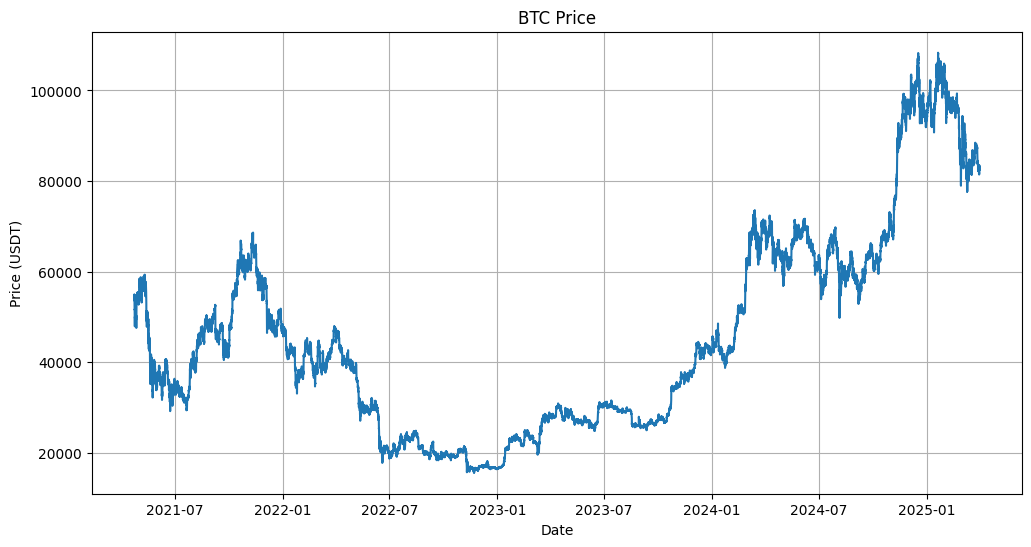

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(btc_spot['close_time'], btc_spot['close'])
plt.title('BTC Price')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.grid(True)
plt.show()

In [6]:
class DataPreprocessor:
    def __init__(self, spot_data, funding_data):
        """
        Initialize the DataPreprocessor with spot and funding data.
        """
        self.spot_data = spot_data
        self.funding_data = funding_data
        self.merged_data = {}
        self.aligned_data = {}
        
    def compute_percent_return(self, df):
        """
        Compute percentage return from open to close price.
        """
        df['percent_return'] = ((df['close'] - df['open']) / df['open']) * 100
        return df
    
    def resample_spot_data(self, spot_df):
        """
        Resample spot price data to 8-hour intervals to match funding rate windows.
        """
        resampled = spot_df.resample('8H', on='close_time').agg({
            'open': 'first',
            'close': 'last',
            'high': 'max',
            'low': 'min',
            'open_time': 'first',
            'close_time': 'last'
        }).reset_index(drop=True)
        
        return resampled
    
    def merge_spot_and_funding(self, spot_df, funding_df):
        """
        Merge spot price and funding rate data.
        """
        spot_8h = self.resample_spot_data(spot_df)
        merged = pd.merge_asof(
            spot_8h, 
            funding_df,
            left_on='open_time', 
            right_on='fundingTime',
            direction='nearest'
        )
        
        merged = self.compute_percent_return(merged)
        
        return merged
    
    def align_timeframe(self, df):
        """
        Align the opening and closing candles of the coin to the nearest funding time window.
        """

        first_open_time = df.iloc[0]['open_time']
        open_funding_time = df.iloc[0]['fundingTime'] - timedelta(minutes=1)
        close_funding_time = open_funding_time + timedelta(hours=8, minutes=2)
        
        slicer = None
        for i in range(len(df)):
            open_time = df.iloc[i]['open_time']
            close_time = df.iloc[i]['close_time']
            if (open_time >= open_funding_time) and (close_time <= close_funding_time):
                slicer = i
                break
        
        if slicer is not None:
            df = df.iloc[slicer:].reset_index(drop=True)
            print(f"Aligned data from row: {slicer}")
        else:
            print('No valid row found within the funding window.')
        
        return df
    
    def create_lagged_features(self, df):
        """
        Create time-lagged features for funding rates.
        """
        # Set fundingTime as index for shifting
        df.set_index('fundingTime', inplace=True)
        
        df['lag_8h_fundingRate'] = df['fundingRate'].shift(1)  # 8 hours
        df['lag_16h_fundingRate'] = df['fundingRate'].shift(2)  # 16 hours
        df['lag_24h_fundingRate'] = df['fundingRate'].shift(3)  # 24 hours
        df['lag_48h_fundingRate'] = df['fundingRate'].shift(6)  # 48 hours
        df['lag_1w_fundingRate'] = df['fundingRate'].shift(21)  # 1 week
        
        df.reset_index(inplace=True)
        
        return df
    
    def process_all_pairs(self):
        """
        Process all cryptocurrency pairs.
        """
        # Process each spot-funding pair
        for spot_symbol, spot_df in self.spot_data.items():
            # Get corresponding perpetual symbol
            perp_symbol = spot_symbol.replace('USDT', 'USD').upper() + '_PERP'
            
            if perp_symbol in self.funding_data:
                funding_df = self.funding_data[perp_symbol]
                
                merged_df = self.merge_spot_and_funding(spot_df, funding_df)
                aligned_df = self.align_timeframe(merged_df)
                processed_df = self.create_lagged_features(aligned_df)

                coin_name = spot_symbol[:-4].lower()
                self.merged_data[f'merged_{coin_name}'] = processed_df
                
                print(f"Processed {spot_symbol} + {perp_symbol}")
        
        return self.merged_data
    
    def get_clean_data(self):
        """
        Get clean data with NaN values removed.

        """
        clean_data = {}
        
        for key, df in self.merged_data.items():
            clean_df = df.dropna(subset=[
                'lag_8h_fundingRate', 
                'lag_16h_fundingRate',
                'lag_24h_fundingRate', 
                'lag_48h_fundingRate',
                'lag_1w_fundingRate'
            ])
            
            clean_data[key] = clean_df
            
        return clean_data
    
    def split_by_market_cycles(self, bull1_end=None, bear_end=None):
        """
        Split data into market cycles.
        """
        if bull1_end is None:
            bull1_end = datetime(2022, 4, 1)
            
        if bear_end is None:
            bear_end = datetime(2023, 9, 30)
            
        bull1_data = {}
        bear_data = {}
        bull2_data = {}
        
        for key, df in self.merged_data.items():
            bull1_data[key] = df[df['fundingTime'] < bull1_end]
            bear_data[key] = df[(df['fundingTime'] >= bull1_end) & (df['fundingTime'] < bear_end)]
            bull2_data[key] = df[df['fundingTime'] >= bear_end]
            
        return bull1_data, bear_data, bull2_data
        
    def save_processed_data(self, directory='./processed_data'):
        """
        Save processed data to CSV files.
        """
        os.makedirs(directory, exist_ok=True)
        
        for key, df in self.merged_data.items():
            filename = f"{directory}/{key}.csv"
            df.to_csv(filename, index=True)
            print(f"Saved {filename}")
    
    def load_processed_data(self, directory='./processed_data'):
        """
        Load processed data from CSV files.
        """
        import os
        import glob
        
        self.merged_data = {}
        csv_files = glob.glob(f"{directory}/*.csv")
        
        for file in csv_files:
            # Get key from filename
            key = os.path.basename(file).replace('.csv', '')
            
            df = pd.read_csv(file)
            if 'fundingTime' in df.columns:
                df['fundingTime'] = pd.to_datetime(df['fundingTime'])
                
            for col in ['open_time', 'close_time']:
                if col in df.columns:
                    df[col] = pd.to_datetime(df[col])
            
            if 'index' in df.columns:
                df.set_index('index', inplace=True)
                
            self.merged_data[key] = df
            print(f"Loaded {file}")
            
        return self.merged_data

In [7]:
preprocessor = DataPreprocessor(spot_data, funding_data)
merged_data = preprocessor.process_all_pairs()
clean_data = preprocessor.get_clean_data()

Aligned data from row: 1
Processed BTCUSDT + BTCUSD_PERP
Aligned data from row: 1
Processed ETHUSDT + ETHUSD_PERP
Aligned data from row: 400
Processed SOLUSDT + SOLUSD_PERP
Aligned data from row: 1
Processed DOGEUSDT + DOGEUSD_PERP
Aligned data from row: 1
Processed BNBUSDT + BNBUSD_PERP
Aligned data from row: 1
Processed LINKUSDT + LINKUSD_PERP
Aligned data from row: 751
Processed AAVEUSDT + AAVEUSD_PERP
Aligned data from row: 1
Processed UNIUSDT + UNIUSD_PERP
Aligned data from row: 1
Processed ADAUSDT + ADAUSD_PERP
Aligned data from row: 1
Processed DOTUSDT + DOTUSD_PERP


In [8]:
print("Checking merged data for BTC:")
print(f"Shape: {merged_data['merged_btc'].shape}")

merged_data['merged_btc'].head()

Checking merged data for BTC:
Shape: (4320, 16)


,fundingTime,open,close,high,low,open_time,close_time,symbol,fundingRate,markPrice,percent_return,lag_8h_fundingRate,lag_16h_fundingRate,lag_24h_fundingRate,lag_48h_fundingRate,lag_1w_fundingRate
0,2021-04-22 08:00:00.007,54146.01,54651.64,55521.48,53080.00,2021-04-22 08:00:00,2021-04-22 15:59:59.999,BTCUSD_PERP,0.000157,NaN,0.933827,NaN,NaN,NaN,NaN,NaN
1,2021-04-22 16:00:00.004,54651.63,51690.96,55166.19,50500.00,2021-04-22 16:00:00,2021-04-22 23:59:59.999,BTCUSD_PERP,0.000316,NaN,-5.417350,0.000157,NaN,NaN,NaN,NaN
2,2021-04-23 00:00:00.007,51690.95,47942.44,52131.85,47700.00,2021-04-23 00:00:00,2021-04-23 07:59:59.999,BTCUSD_PERP,0.000100,NaN,-7.251772,0.000316,0.000157,NaN,NaN,NaN
3,2021-04-23 08:00:00.008,47936.00,49836.62,50300.00,47500.00,2021-04-23 08:00:00,2021-04-23 15:59:59.999,BTCUSD_PERP,0.000100,NaN,3.964912,0.000100,0.000316,0.000157,NaN,NaN
4,2021-04-23 16:00:00.015,49836.63,51125.14,51301.34,49470.26,2021-04-23 16:00:00,2021-04-23 23:59:59.999,BTCUSD_PERP,0.000093,NaN,2.585468,0.000100,0.000100,0.000316,NaN,NaN


In [9]:
bull1_end = datetime(2022, 5, 1)  
bear_end = datetime(2023, 9, 30)  

bull1_data, bear_data, bull2_data = preprocessor.split_by_market_cycles(bull1_end, bear_end)
preprocessor.save_processed_data()

Saved ./processed_data/merged_btc.csv
Saved ./processed_data/merged_eth.csv
Saved ./processed_data/merged_sol.csv
Saved ./processed_data/merged_doge.csv
Saved ./processed_data/merged_bnb.csv
Saved ./processed_data/merged_link.csv
Saved ./processed_data/merged_aave.csv
Saved ./processed_data/merged_uni.csv
Saved ./processed_data/merged_ada.csv
Saved ./processed_data/merged_dot.csv


In [10]:
print(f"\nBTC periods by market cycle:")
print(f"Bull Market 1: {len(bull1_data['merged_btc'])}")
print(f"Bear Market: {len(bear_data['merged_btc'])}")
print(f"Bull Market 2: {len(bull2_data['merged_btc'])}")


BTC periods by market cycle:
Bull Market 1: 1121
Bear Market: 1551
Bull Market 2: 1648


In [11]:
class MarketAnalyser:
    """
    Class for analyzing cryptocurrency market data and generating visualizations.
    """
    
    def __init__(self, merged_data=None, bull1_data=None, bear_data=None, bull2_data=None):
        self.merged_data = merged_data or {}
        self.bull1_data = bull1_data or {}
        self.bear_data = bear_data or {}
        self.bull2_data = bull2_data or {}
        
        # Set up plotting style
        sns.set_style("whitegrid")
        plt.rcParams['figure.figsize'] = (12, 8)
        plt.rcParams['font.size'] = 12
        
    def set_data(self, merged_data, bull1_data=None, bear_data=None, bull2_data=None):
        """
        Set market data for analysis.
        """
        self.merged_data = merged_data
        
        if bull1_data is not None:
            self.bull1_data = bull1_data
        if bear_data is not None:
            self.bear_data = bear_data
        if bull2_data is not None:
            self.bull2_data = bull2_data
    
    def plot_price_and_funding(self, coin='btc', save_path=None, display=False):
        """
        Plot price and funding rate for a specific coin.
        """
        key = f'merged_{coin}'
        if key not in self.merged_data:
            print(f"No data found for {coin}")
            return None
        
        df = self.merged_data[key]
        
        fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
        
        axs[0].plot(df['open_time'], df['close'], color='blue')
        axs[0].set_title(f'{coin.upper()} Price', fontsize=16)
        axs[0].set_ylabel('Price (USDT)', fontsize=14)
        axs[0].grid(True)

        funding_rate_pct = df['fundingRate'] * 100
        color_map = ['green' if rate > 0 else 'red' for rate in funding_rate_pct]
        
        axs[1].bar(df['open_time'], funding_rate_pct, color=color_map, alpha=0.7, width=5)
        axs[1].set_title(f'{coin.upper()} Funding Rate', fontsize=16)
        axs[1].set_xlabel('Date', fontsize=14)
        axs[1].set_ylabel('Funding Rate (%)', fontsize=14)
        

        max_abs_rate = max(abs(funding_rate_pct.min()), abs(funding_rate_pct.max()))
        y_limit = max(0.1, max_abs_rate * 1.1)  
        axs[1].set_ylim(-y_limit, y_limit)
        
        axs[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axs[1].grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")

        if not display:
            plt.close()
        
        return fig
    
    def plot_correlation_matrix(self, coin='btc', save_path=None, display=False):
        """
        Plot correlation matrix for a specific coin.
        """
        key = f'merged_{coin}'
        if key not in self.merged_data:
            print(f"No data found for {coin}")
            return None
        
        df = self.merged_data[key]
        cols = ['percent_return', 'fundingRate', 'lag_8h_fundingRate', 
                'lag_16h_fundingRate', 'lag_24h_fundingRate', 
                'lag_48h_fundingRate', 'lag_1w_fundingRate']
        
        corr_matrix = df[cols].corr()
        
        # Plot correlation matrix
        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # Generate a custom diverging colormap
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        
        # Draw the heatmap with the mask and correct aspect ratio
        sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.3, vmin=-.3, center=0,
                    square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt='.3f')
        
        ax.set_title(f'{coin.upper()} - Correlation Matrix', fontsize=16)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")

        if not display:
            plt.close()
        
        return fig
    
    def calculate_stats(self, data_dict, metric='fundingRate'):
        """
        Calculate statistics for a specific metric across all coins.
        """
        stats = {}
        
        for key, df in data_dict.items():
            coin = key.split('_')[1].upper()
            
            if metric in df.columns:
                stats[coin] = {
                    'Mean': df[metric].mean(),
                    'Median': df[metric].median(),
                    'Std Dev': df[metric].std(),
                    'Min': df[metric].min(),
                    'Max': df[metric].max(),
                    'Skew': df[metric].skew(),
                    'Kurtosis': df[metric].kurtosis()
                }
        
        # Convert to DataFrame
        stats_df = pd.DataFrame(stats).T
        
        return stats_df
    
    def plot_funding_rate_distribution(self, save_path=None, display=False):
        """
        Plot distribution of funding rates across all coins.
        """
        # Prepare data
        funding_rates = {}
        
        for key, df in self.merged_data.items():
            coin = key.split('_')[1].upper()
            funding_rates[coin] = df['fundingRate'] * 100 
        
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Plot distributions
        sns.boxplot(data=funding_rates, ax=ax, showfliers=False)
        
        ax.set_title('Distribution of Funding Rates by Coin', fontsize=16)
        ax.set_ylabel('Funding Rate (%)', fontsize=14)
        ax.set_xlabel('Coin', fontsize=14)
        ax.grid(True, axis='y')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        if not display:
            plt.close()

        return fig
    
    def plot_market_cycle_comparison(self, coin='btc', metric='fundingRate', save_path=None, display=False):
        """
        Plot comparison of a metric across market cycles.
        """
        key = f'merged_{coin}'
        
        if (key not in self.bull1_data) or (key not in self.bear_data) or (key not in self.bull2_data):
            print(f"Missing cycle data for {coin}")
            return None
        
        bull1_values = self.bull1_data[key][metric] * 100 if metric == 'fundingRate' else self.bull1_data[key][metric]
        bear_values = self.bear_data[key][metric] * 100 if metric == 'fundingRate' else self.bear_data[key][metric]
        bull2_values = self.bull2_data[key][metric] * 100 if metric == 'fundingRate' else self.bull2_data[key][metric]
        
        fig, ax = plt.subplots(figsize=(12, 8))
        data = [bull1_values, bear_values, bull2_values]
        labels = ['Bull Market 1', 'Bear Market', 'Bull Market 2']
        parts = ax.violinplot(data, showmeans=True, showextrema=True)
        
        for i, pc in enumerate(parts['bodies']):
            if i == 0:  # Bull 1
                pc.set_facecolor('green')
                pc.set_alpha(0.7)
            elif i == 1:  # Bear
                pc.set_facecolor('red')
                pc.set_alpha(0.7)
            else:  # Bull 2
                pc.set_facecolor('blue')
                pc.set_alpha(0.7)
        
        # Set labels
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(labels)
        
        if metric == 'fundingRate':
            ax.set_ylabel('Funding Rate (%)', fontsize=14)
            ax.set_title(f'{coin.upper()} - Funding Rate Across Market Cycles', fontsize=16)
        else:
            ax.set_ylabel('Return (%)', fontsize=14)
            ax.set_title(f'{coin.upper()} - Returns Across Market Cycles', fontsize=16)
        
        # Add horizontal line at 0
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        
        # Add statistics
        stats_text = (
            f"Bull 1: mean={bull1_values.mean():.3f}, median={bull1_values.median():.3f}\n"
            f"Bear: mean={bear_values.mean():.3f}, median={bear_values.median():.3f}\n"
            f"Bull 2: mean={bull2_values.mean():.3f}, median={bull2_values.median():.3f}"
        )
        
        ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.grid(True, axis='y')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")

        if not display:
            plt.close()
        
        return fig
    
    def compare_correlation_across_cycles(self, save_path=None, display=False):
        """
        Compare correlation between funding rates and returns across market cycles.
        """
        correlations = {
            'Bull Market 1': {},
            'Bear Market': {},
            'Bull Market 2': {}
        }
        
        for key in self.merged_data.keys():
            coin = key.split('_')[1].upper()
            
            if key in self.bull1_data:
                corr = self.bull1_data[key]['fundingRate'].corr(self.bull1_data[key]['percent_return'])
                correlations['Bull Market 1'][coin] = corr
            
            if key in self.bear_data:
                corr = self.bear_data[key]['fundingRate'].corr(self.bear_data[key]['percent_return'])
                correlations['Bear Market'][coin] = corr
            
            if key in self.bull2_data:
                corr = self.bull2_data[key]['fundingRate'].corr(self.bull2_data[key]['percent_return'])
                correlations['Bull Market 2'][coin] = corr
        
        corr_df = pd.DataFrame(correlations)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-0.2, vmax=0.2, ax=ax)
        
        ax.set_title('Correlation Between Funding Rates and Returns Across Market Cycles', fontsize=16)
        ax.set_ylabel('Coin', fontsize=14)
        ax.set_xlabel('Market Cycle', fontsize=14)

        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")

        if not display:
            plt.close()
        
        return fig, corr_df
    
    def analyse_market_conditions(self):
        """
        Analyse market conditions and print summary statistics.
        """
        summary = {}
        
        summary['Bull Market 1'] = self.calculate_stats(self.bull1_data, 'fundingRate')
        summary['Bear Market'] = self.calculate_stats(self.bear_data, 'fundingRate')
        summary['Bull Market 2'] = self.calculate_stats(self.bull2_data, 'fundingRate')
        
        # Print summary statistics
        print("=== Funding Rate Statistics Across Market Cycles ===")
        
        for cycle, stats in summary.items():
            print(f"\n{cycle} Statistics:")
            print(stats.to_string())
        
        return summary
    
    def create_comprehensive_report(self, output_dir='./analysis_report'):
        """
        Create a comprehensive analysis report with multiple visualizations.
        """
        import os
        
        os.makedirs(output_dir, exist_ok=True)
        
        figures = {}
        for key in self.merged_data.keys():
            coin = key.split('_')[1]
            save_path = f"{output_dir}/{coin}_price_and_funding.png"
            figures[f"{coin}_price_funding"] = self.plot_price_and_funding(coin, save_path)
        
        for key in self.merged_data.keys():
            coin = key.split('_')[1]
            save_path = f"{output_dir}/{coin}_correlation_matrix.png"
            figures[f"{coin}_correlation"] = self.plot_correlation_matrix(coin, save_path)
        
        save_path = f"{output_dir}/funding_rate_distribution.png"
        figures["funding_distribution"] = self.plot_funding_rate_distribution(save_path)
        
        selected_coins = ['btc', 'eth', 'sol', 'doge']
        for coin in selected_coins:
            # Funding rate comparison
            save_path = f"{output_dir}/{coin}_funding_rate_cycles.png"
            figures[f"{coin}_funding_cycles"] = self.plot_market_cycle_comparison(
                coin, 'fundingRate', save_path)
            
            # Return comparison
            save_path = f"{output_dir}/{coin}_return_cycles.png"
            figures[f"{coin}_return_cycles"] = self.plot_market_cycle_comparison(
                coin, 'percent_return', save_path)
        
        save_path = f"{output_dir}/correlation_across_cycles.png"
        figures["correlation_cycles"], corr_df = self.compare_correlation_across_cycles(save_path)
        

        corr_df.to_csv(f"{output_dir}/correlation_across_cycles.csv")
        summary = self.analyse_market_conditions()
        
        for cycle, stats in summary.items():
            stats.to_csv(f"{output_dir}/{cycle.replace(' ', '_').lower()}_stats.csv")
        
        print(f"Comprehensive report generated in {output_dir}")
        
        return figures

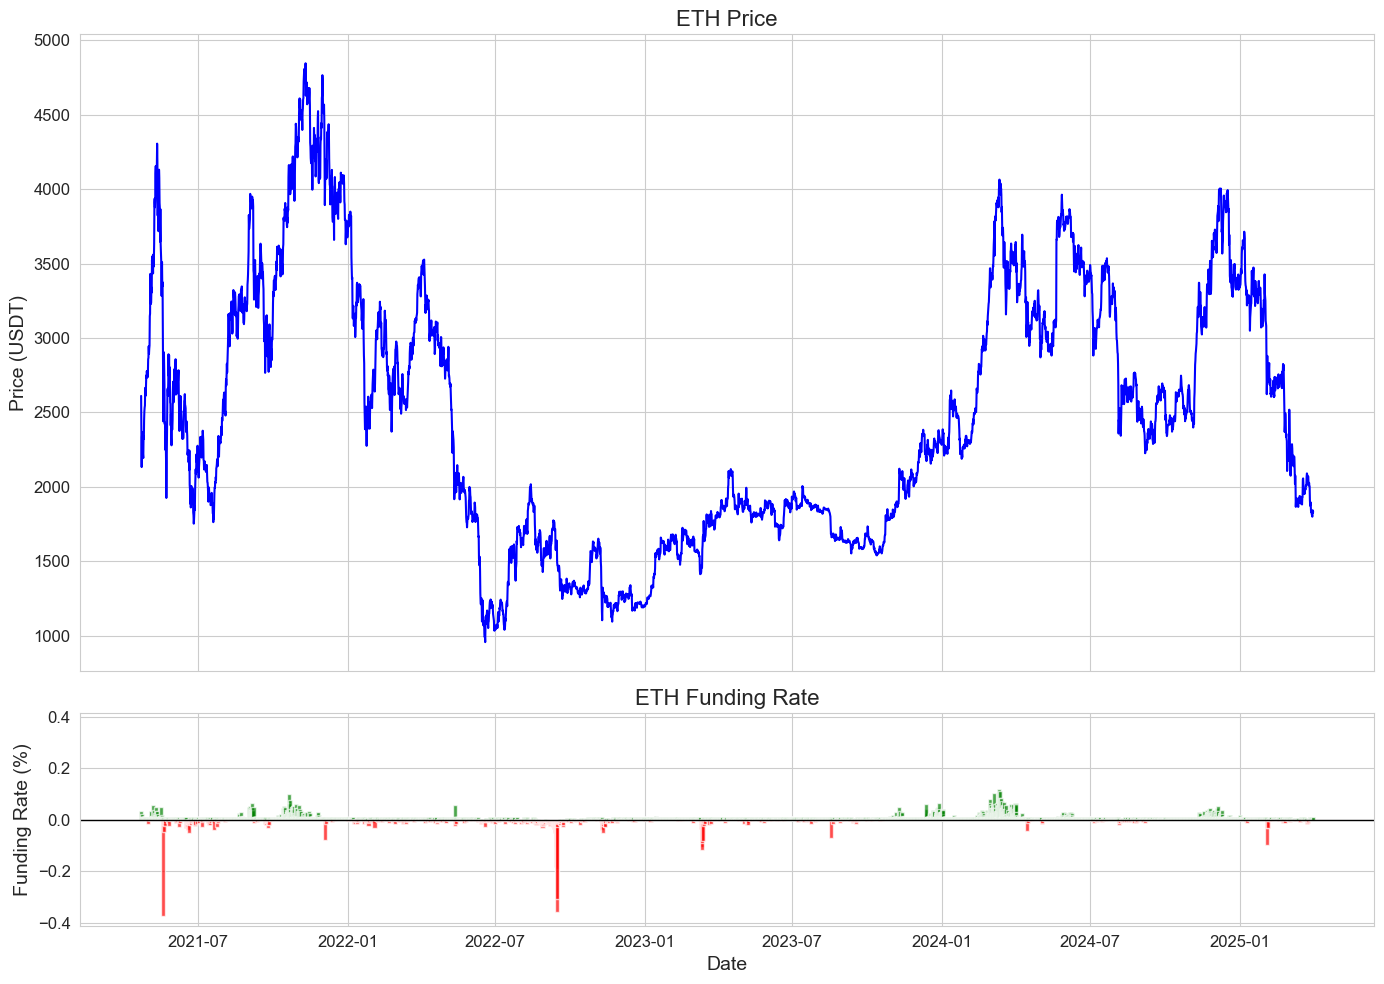

In [12]:
analyser = MarketAnalyser(merged_data, bull1_data, bear_data, bull2_data)
analyser.plot_price_and_funding('eth')

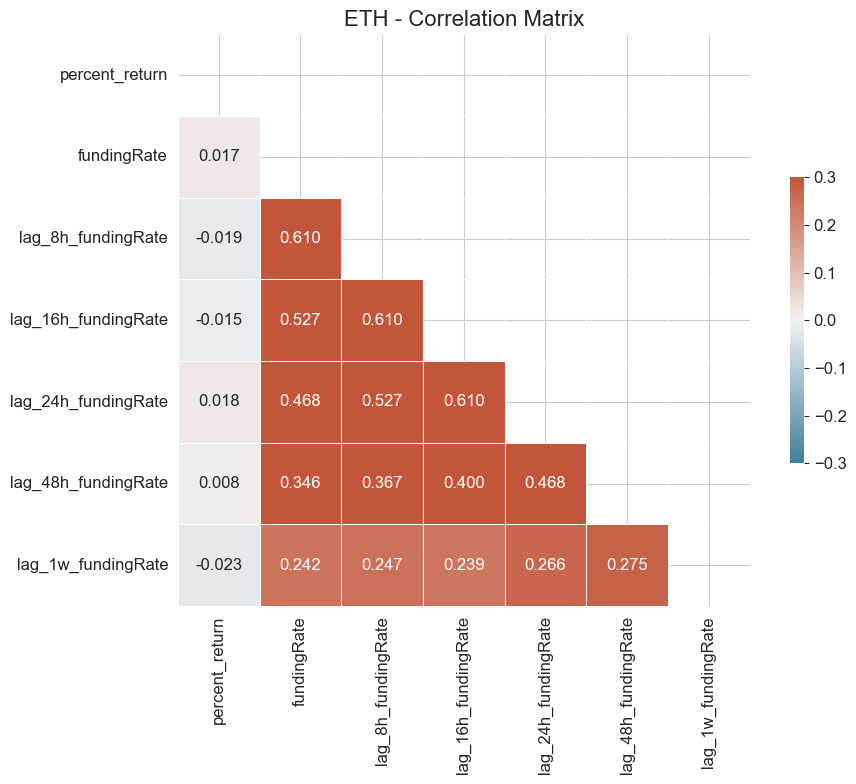

In [13]:
analyser.plot_correlation_matrix('eth')

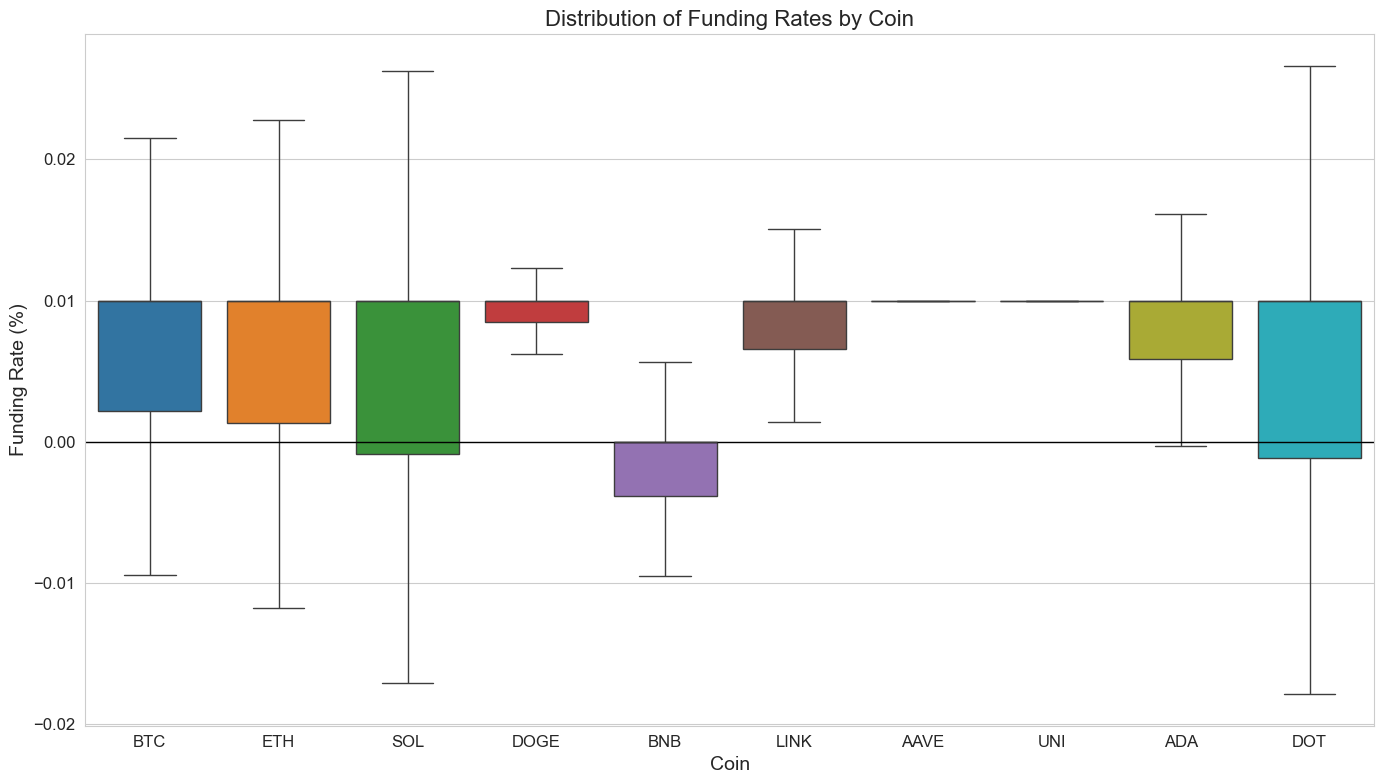

In [14]:
analyser.plot_funding_rate_distribution()

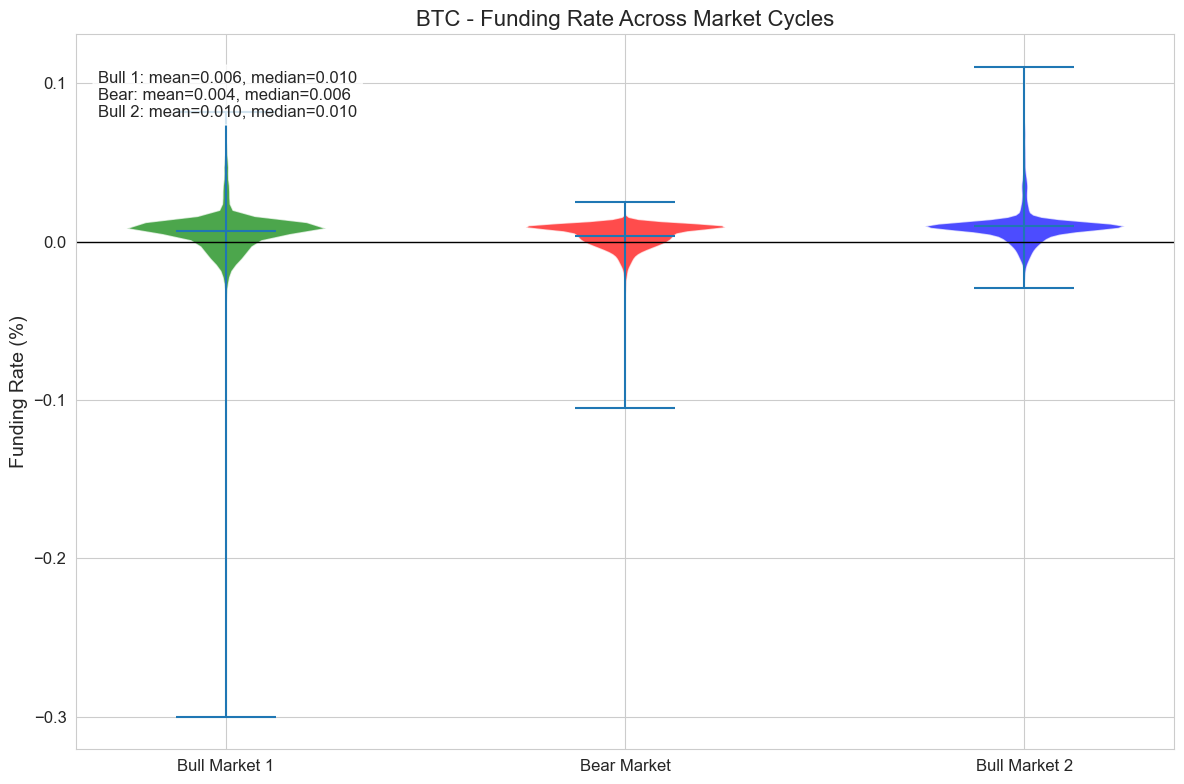

In [15]:
analyser.plot_market_cycle_comparison('btc', 'fundingRate')

In [16]:
corr_fig, corr_df = analyser.compare_correlation_across_cycles()

## Funding Rates Across Market Cycles

My analysis of funding rates across bull and bear markets revealed:

1. **Bull Market Bias**: Funding rates tend to be more consistently positive during bull markets, reflecting optimistic trader sentiment and greater willingness to pay premiums for leverage.

2. **Bear Market Volatility**: During bear markets, funding rates showed greater volatility and more frequent negative values, indicating market uncertainty and periodic short-biased positioning.

3. **Correlation Shifts**: The correlation between funding rates and subsequent returns showed some variation across market cycles, but remained consistently weak, confirming the lack of reliable predictive signal regardless of broader market conditions.

In [17]:
print("\nCorrelation between Funding Rates and Returns across cycles:")
display(corr_df)

max_corr = corr_df.max().max()
min_corr = corr_df.min().min()
print(f"\nHighest correlation: {max_corr:.3f}")
print(f"Lowest correlation: {min_corr:.3f}")


Correlation between Funding Rates and Returns across cycles:


,Bull Market 1,Bear Market,Bull Market 2
BTC,-0.056986,-0.091365,-0.001887
ETH,0.039477,0.013515,-0.012682
SOL,0.015689,0.093501,-0.022095
DOGE,-0.109347,-0.020127,-0.029776
BNB,-0.052182,-0.025134,0.026974
LINK,0.019985,-0.055502,-0.056533
AAVE,-0.071803,0.040203,-0.032962
UNI,0.033519,-0.057078,0.006049
ADA,-0.051129,-0.071159,-0.084773
DOT,-0.030033,-0.003894,-0.069922



Highest correlation: 0.094
Lowest correlation: -0.109


## Funding Rates as Price Predictors: Findings

My analysis across multiple cryptocurrencies (BTC, ETH, SOL, DOGE) reveals a consistent pattern of negative R² values for all tested models. This indicates that:

1. **Poor Predictive Power**: All models performed worse than simply predicting the mean return. Negative R² values conclusively demonstrate that the models fail to capture useful relationships between funding rates and future price movements.

2. **Market Inefficiency Not Exploitable**: While funding rates represent market sentiment and positioning, my analysis shows they cannot be reliably used to predict short-term price movements.

3. **Complexity of Crypto Markets**: The models' failure suggests that cryptocurrency price movements are influenced by a complex mix of factors beyond just funding rates and their historical patterns.

4. **Trading Strategy Implications**: The backtest results demonstrate that strategies based solely on funding rate signals would likely underperform a simple buy-and-hold approach over the analysed period.


Coin with strongest correlation: DOGE


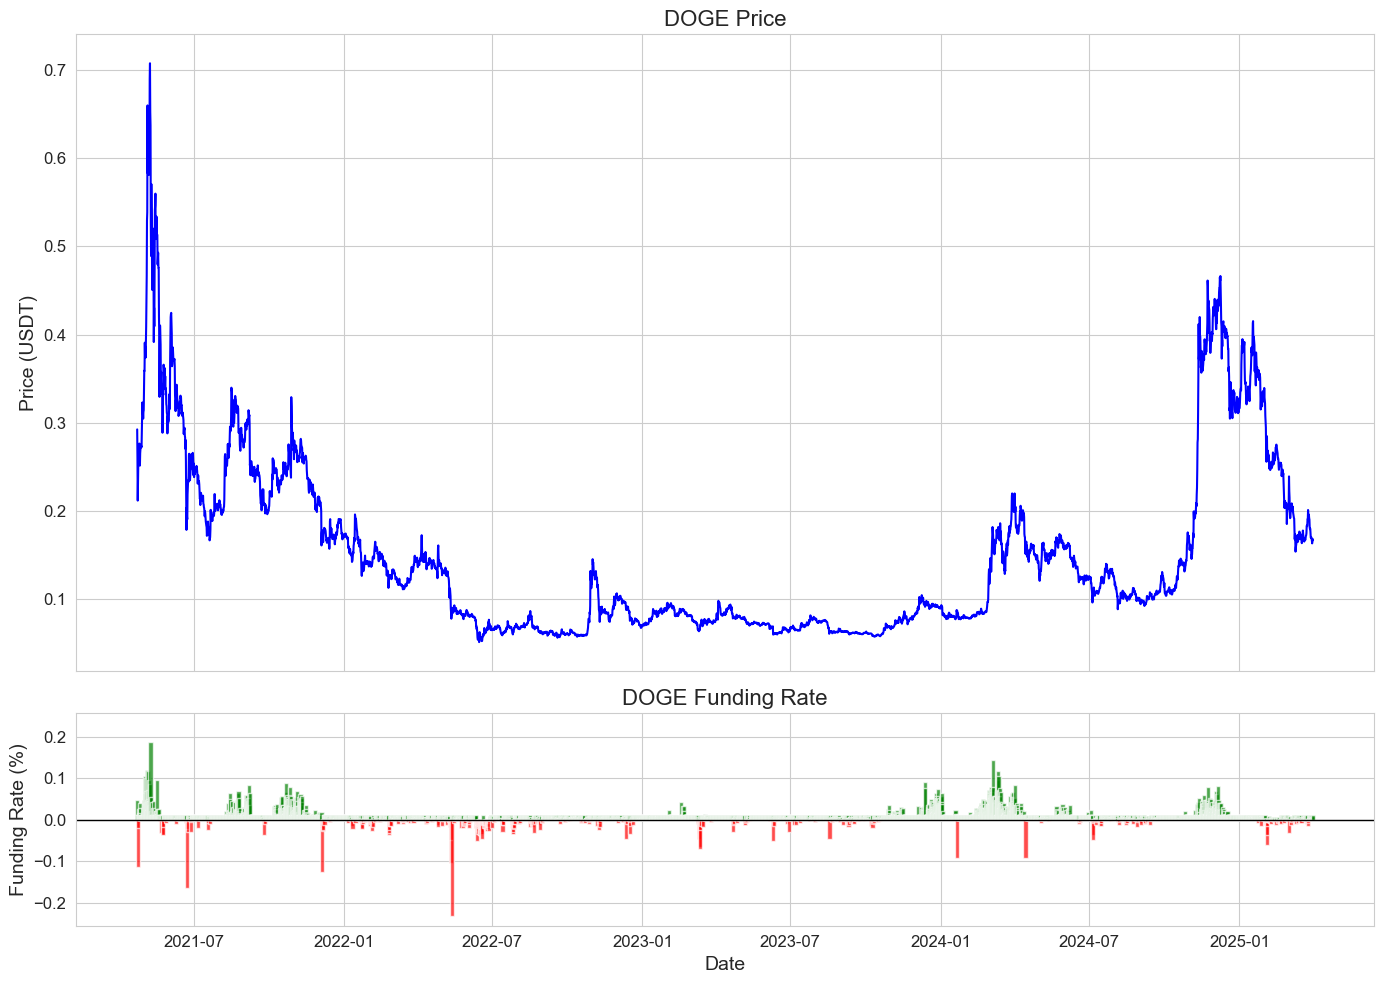

In [18]:
strongest_coin = corr_df.abs().max(axis=1).idxmax()
print(f"\nCoin with strongest correlation: {strongest_coin}")
analyser.plot_price_and_funding(strongest_coin.lower())

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

class ModelBuilder:
    """
    Class for building and evaluating prediction models.
    """
    
    def __init__(self, merged_data=None):
        self.merged_data = merged_data or {}
        self.models = {}
        self.results = {}
        self.feature_importance = {}
        sns.set_style("whitegrid")
        plt.rcParams['figure.figsize'] = (12, 8)
        plt.rcParams['font.size'] = 12
    
    def set_data(self, merged_data):
        """
        Set market data for modeling.
        """
        self.merged_data = merged_data
    
    def create_features(self, df, window_sizes=[8, 24, 72]):
        """
        Create advanced features for modeling.
        """
        df_features = df.copy()
        datetime_cols = ['fundingTime', 'open_time', 'close_time']
        
        for window in window_sizes:
            # Rolling mean of funding rates
            df_features[f'fundingRate_mean_{window}'] = df['fundingRate'].rolling(window=window).mean()
            
            # Rolling standard deviation of funding rates
            df_features[f'fundingRate_std_{window}'] = df['fundingRate'].rolling(window=window).std()
            
            # Z-score of funding rates
            df_features[f'fundingRate_zscore_{window}'] = (
                df['fundingRate'] - df_features[f'fundingRate_mean_{window}']
            ) / df_features[f'fundingRate_std_{window}'].replace(0, np.nan)
            
            # Exponentially weighted mean of funding rates
            df_features[f'fundingRate_ewm_{window}'] = df['fundingRate'].ewm(span=window).mean()
            
            # Funding rate momentum (change over window)
            df_features[f'fundingRate_momentum_{window}'] = df['fundingRate'] - df['fundingRate'].shift(window)
        

        for window in window_sizes:
            # Price momentum
            df_features[f'price_momentum_{window}'] = df['close'].pct_change(window)
            
            # Volatility
            df_features[f'volatility_{window}'] = df['close'].pct_change().rolling(window=window).std()
            
            # Relative strength index (RSI)
            delta = df['close'].diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
            rs = gain / loss.replace(0, np.nan)
            df_features[f'rsi_{window}'] = 100 - (100 / (1 + rs))
        
        # Interaction between funding rate and volatility
        for window in window_sizes:
            df_features[f'funding_vol_interaction_{window}'] = (
                df_features[f'fundingRate_zscore_{window}'] * df_features[f'volatility_{window}']
            )
        
        for lag in [1, 3, 8, 24]:
            df_features[f'return_lag_{lag}'] = df['percent_return'].shift(lag)
        
        df_features['target_return'] = df['percent_return'].shift(-1)
        
        # Drop rows with NaN values
        df_features = df_features.dropna()
        
        return df_features
    
    def train_test_split_time(self, df, test_size=0.2):
        """
        Split data into train and test sets based on time.
        """
        df = df.sort_index()
        split_idx = int(len(df) * (1 - test_size))
        
        train = df.iloc[:split_idx]
        test = df.iloc[split_idx:]

        feature_cols = [col for col in df.columns if (
            col != 'target_return' and 
            col != 'percent_return' and
            col != 'open' and
            col != 'high' and
            col != 'low' and
            col != 'close' and
            col != 'fundingTime' and
            col != 'open_time' and
            col != 'close_time' and
            col != 'symbol' and
            col != 'markPrice'
        )]
        
        X_train = train[feature_cols]
        y_train = train['target_return']
        
        X_test = test[feature_cols]
        y_test = test['target_return']
        
        return X_train, X_test, y_train, y_test, feature_cols
    
    def evaluate_model(self, y_true, y_pred, model_name="Model"):
        """
        Evaluate model performance.
        """
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        print(f"{model_name} Performance:")
        print(f"MSE: {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print("-" * 50)
        
        return {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    
    def build_models(self, coin='btc', test_size=0.2):
        """
        Build and evaluate multiple models for a specific coin.
        """
        key = f'merged_{coin}'
        if key not in self.merged_data:
            print(f"No data found for {coin}")
            return None
        

        df = self.merged_data[key]
        df_features = self.create_features(df)
        X_train, X_test, y_train, y_test, feature_cols = self.train_test_split_time(df_features, test_size)
        
        print(f"Training data shape: {X_train.shape}")
        print(f"Test data shape: {X_test.shape}")
        
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
        }
        
        results = {}
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            metrics = self.evaluate_model(y_test, y_pred, name)
            
            results[name] = {
                'model': model,
                'metrics': metrics,
                'predictions': y_pred,
                'actual': y_test,
                'feature_cols': feature_cols
            }
            
            if hasattr(model, 'feature_importances_'):
                feature_importance = pd.DataFrame({
                    'Feature': feature_cols,
                    'Importance': model.feature_importances_
                }).sort_values('Importance', ascending=False)
                
                self.feature_importance[f"{coin}_{name}"] = feature_importance
        
        self.models[coin] = models
        self.results[coin] = results
        
        return results
    
    def plot_feature_importance(self, coin='btc', model_name='Random Forest', top_n=20, save_path=None):
        """
        Plot feature importance for a specific model.
        """
        key = f"{coin}_{model_name}"
        if key not in self.feature_importance:
            print(f"No feature importance found for {key}")
            return None
        
        importance = self.feature_importance[key]
        importance = importance.head(top_n)
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
        sns.barplot(x='Importance', y='Feature', data=importance, ax=ax)
        
        ax.set_title(f'{coin.upper()} - {model_name} Feature Importance', fontsize=16)
        ax.set_xlabel('Importance', fontsize=14)
        ax.set_ylabel('Feature', fontsize=14)
        
        plt.tight_layout()
        
        # Save plot if path provided
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        return fig
    
    def plot_actual_vs_predicted(self, coin='btc', model_name='Random Forest', save_path=None):
        """
        Plot actual vs predicted values for a specific model.
        """
        if (coin not in self.results) or (model_name not in self.results[coin]):
            print(f"No results found for {coin} - {model_name}")
            return None
        
        results = self.results[coin][model_name]
        y_test = results['actual']
        y_pred = results['predictions']
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
        ax.scatter(y_test, y_pred, alpha=0.5)
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
        
        ax.set_title(f'{coin.upper()} - {model_name} Actual vs Predicted', fontsize=16)
        ax.set_xlabel('Actual Return (%)', fontsize=14)
        ax.set_ylabel('Predicted Return (%)', fontsize=14)
        
        # Add R-squared value to plot
        r2 = results['metrics']['r2']
        ax.text(0.05, 0.95, f"R² = {r2:.4f}", transform=ax.transAxes, fontsize=14,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.grid(True)
        
        plt.tight_layout()
        
        # Save plot if path provided
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        return fig
    
    def backtest_trading_strategy(self, coin='btc', model_name='Random Forest', save_path=None):
        """
        Backtest a trading strategy based on model predictions.
        """
        if (coin not in self.results) or (model_name not in self.results[coin]):
            print(f"No results found for {coin} - {model_name}")
            return None, None
        
        results = self.results[coin][model_name]
        y_test = results['actual']
        y_pred = results['predictions']
        
        key = f'merged_{coin}'
        df = self.merged_data[key]
        df_features = self.create_features(df)
        
        split_idx = int(len(df_features) * 0.8) 
        test_data = df_features.iloc[split_idx:]
        test_data = test_data.iloc[:len(y_test)]
        
        # Generate signals: 1 for buy (positive prediction), -1 for sell (negative prediction)
        signals = np.sign(y_pred)
        
        strategy_returns = signals * y_test
        
        if 'close_time' in test_data.columns:
            strategy_returns_plot = pd.Series(strategy_returns.values, index=test_data['close_time'])
            actual_returns_plot = pd.Series(y_test.values, index=test_data['close_time'])
        else:
            strategy_returns_plot = pd.Series(strategy_returns, index=y_test.index)
            actual_returns_plot = pd.Series(y_test, index=y_test.index)
        
        cumulative_actual = (1 + actual_returns_plot / 100).cumprod() - 1
        cumulative_strategy = (1 + strategy_returns_plot / 100).cumprod() - 1
        
        total_return_actual = cumulative_actual.iloc[-1]
        total_return_strategy = cumulative_strategy.iloc[-1]
        
        sharpe_actual = y_test.mean() / y_test.std() * np.sqrt(365)
        sharpe_strategy = strategy_returns.mean() / strategy_returns.std() * np.sqrt(365)
        
        # Maximum drawdown
        def calculate_max_drawdown(returns):
            cum_returns = (1 + returns / 100).cumprod()
            running_max = cum_returns.cummax()
            drawdown = (cum_returns / running_max) - 1
            return drawdown.min()
        
        max_dd_actual = calculate_max_drawdown(y_test)
        max_dd_strategy = calculate_max_drawdown(strategy_returns)
        
        # Create figure
        fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})
        
        cumulative_actual.plot(ax=axes[0], label='Buy & Hold', color='blue')
        cumulative_strategy.plot(ax=axes[0], label='Strategy', color='green')
        
        axes[0].set_title(f'{coin.upper()} - {model_name} Trading Strategy Performance', fontsize=16)
        axes[0].set_xlabel('Date', fontsize=14)
        axes[0].set_ylabel('Cumulative Return', fontsize=14)
        axes[0].legend()
        axes[0].grid(True)
        
        metrics_text = (
            f"Buy & Hold: Return={total_return_actual:.2%}, Sharpe={sharpe_actual:.2f}, Max DD={max_dd_actual:.2%}\n"
            f"Strategy: Return={total_return_strategy:.2%}, Sharpe={sharpe_strategy:.2f}, Max DD={max_dd_strategy:.2%}"
        )
        
        axes[0].text(0.02, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        drawdown_actual = (cumulative_actual / cumulative_actual.cummax()) - 1
        drawdown_strategy = (cumulative_strategy / cumulative_strategy.cummax()) - 1
        
        drawdown_actual.plot(ax=axes[1], label='Buy & Hold Drawdown', color='blue')
        drawdown_strategy.plot(ax=axes[1], label='Strategy Drawdown', color='green')
        
        axes[1].set_title('Drawdown Comparison', fontsize=16)
        axes[1].set_xlabel('Date', fontsize=14)
        axes[1].set_ylabel('Drawdown', fontsize=14)
        axes[1].legend()
        axes[1].grid(True)
        
        plt.tight_layout()
        
        # Save plot if path provided
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        # Performance metrics
        performance = {
            'Total Return (Buy & Hold)': total_return_actual,
            'Total Return (Strategy)': total_return_strategy,
            'Sharpe Ratio (Buy & Hold)': sharpe_actual,
            'Sharpe Ratio (Strategy)': sharpe_strategy,
            'Max Drawdown (Buy & Hold)': max_dd_actual,
            'Max Drawdown (Strategy)': max_dd_strategy
        }
        
        return fig, performance
    
    def perform_cross_validation(self, coin='btc', n_splits=5):
        """
        Perform time series cross-validation.
        """
        key = f'merged_{coin}'
        if key not in self.merged_data:
            print(f"No data found for {coin}")
            return None
        
        df = self.merged_data[key]
        df_features = self.create_features(df)
        
        exclude_columns = ['target_return', 'percent_return', 'open', 'high', 'low', 'close',
                        'fundingTime', 'open_time', 'close_time', 'symbol', 'markPrice']
        
        feature_cols = []
        for col in df_features.columns:
            if col not in exclude_columns:
                if np.issubdtype(df_features[col].dtype, np.number):
                    feature_cols.append(col)
        
        X = df_features[feature_cols]
        y = df_features['target_return']
        
        X = X.apply(pd.to_numeric, errors='coerce')
        X = X.fillna(0)
        
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
        }
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        cv_results = {}
        
        for name, model in models.items():
            print(f"Cross-validating {name}...")
            
            cv_scores = []
            
            for train_idx, test_idx in tscv.split(X):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                cv_scores.append(rmse)
            
            cv_results[name] = {
                'scores': cv_scores,
                'mean': np.mean(cv_scores),
                'std': np.std(cv_scores)
            }
            
            print(f"{name} CV RMSE: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
        
        return cv_results
    
    def generate_model_report(self, coin='btc', output_dir='./model_report'):
        """
        Generate a comprehensive model report.
        """
        import os
        
        os.makedirs(output_dir, exist_ok=True)
        report = {}
        
        results = self.build_models(coin)
        report['model_results'] = results
        
        for model_name in ['Random Forest', 'Gradient Boosting']:
            save_path = f"{output_dir}/{coin}_{model_name.lower().replace(' ', '_')}_feature_importance.png"
            fig = self.plot_feature_importance(coin, model_name, save_path=save_path)
            report[f"{model_name}_feature_importance"] = fig
        
        for model_name in results.keys():
            save_path = f"{output_dir}/{coin}_{model_name.lower().replace(' ', '_')}_actual_vs_predicted.png"
            fig = self.plot_actual_vs_predicted(coin, model_name, save_path=save_path)
            report[f"{model_name}_actual_vs_predicted"] = fig
        
        for model_name in results.keys():
            save_path = f"{output_dir}/{coin}_{model_name.lower().replace(' ', '_')}_backtest.png"
            fig, perf = self.backtest_trading_strategy(coin, model_name, save_path=save_path)
            report[f"{model_name}_backtest"] = (fig, perf)
            
            # Save performance metrics
            perf_df = pd.DataFrame(perf, index=[0]).T
            perf_df.to_csv(f"{output_dir}/{coin}_{model_name.lower().replace(' ', '_')}_performance.csv")
        
        cv_results = self.perform_cross_validation(coin)
        report['cv_results'] = cv_results
        
        cv_df = pd.DataFrame({
            'Model': list(cv_results.keys()),
            'Mean RMSE': [cv_results[model]['mean'] for model in cv_results],
            'Std RMSE': [cv_results[model]['std'] for model in cv_results]
        })
        cv_df.to_csv(f"{output_dir}/{coin}_cv_results.csv", index=False)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for model, res in cv_results.items():
            ax.plot(range(1, len(res['scores']) + 1), res['scores'], 'o-', label=model)
        
        ax.set_title(f'{coin.upper()} - Cross-Validation Results', fontsize=16)
        ax.set_xlabel('CV Fold', fontsize=14)
        ax.set_ylabel('RMSE', fontsize=14)
        ax.legend()
        ax.grid(True)
        
        plt.tight_layout()
        
        save_path = f"{output_dir}/{coin}_cv_results.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved CV results plot to {save_path}")
        
        report['cv_plot'] = fig
        
        print(f"Model report generated in {output_dir}")
        
        return report
    
    def generate_multi_coin_summary(self, coins=['btc', 'eth', 'sol', 'doge'], output_dir='./model_report'):
        """
        Generate a summary of model performance across multiple coins.
        """
        import os
        
        os.makedirs(output_dir, exist_ok=True)
        summary = {
            'Linear Regression': [],
            'Random Forest': [],
            'Gradient Boosting': []
        }
        
        for coin in coins:
            print(f"\nProcessing {coin.upper()}...")
            results = self.build_models(coin)
            
            if results:
                for model_name, result in results.items():
                    summary[model_name].append({
                        'Coin': coin.upper(),
                        'RMSE': result['metrics']['rmse'],
                        'MAE': result['metrics']['mae'],
                        'R2': result['metrics']['r2']
                    })
        
        summary_dfs = {}
        
        for model_name, results in summary.items():
            df = pd.DataFrame(results)
            summary_dfs[model_name] = df
            df.to_csv(f"{output_dir}/{model_name.lower().replace(' ', '_')}_summary.csv", index=False)
        
        fig, ax = plt.subplots(figsize=(12, 8))
        x = np.arange(len(coins))
        width = 0.25
        
        # Plot bars for each model
        for i, (model_name, df) in enumerate(summary_dfs.items()):
            df = df.set_index('Coin')
            values = [df.loc[coin.upper(), 'R2'] for coin in coins]
            ax.bar(x + (i - 1) * width, values, width, label=model_name)
        
        ax.set_xlabel('Coin', fontsize=14)
        ax.set_ylabel('R² Score', fontsize=14)
        ax.set_title('Model Performance Comparison Across Coins', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels([coin.upper() for coin in coins])
        ax.legend()
        ax.grid(True, axis='y')
        
        plt.tight_layout()
        
        save_path = f"{output_dir}/model_performance_comparison.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved model performance comparison to {save_path}")
        
        return summary_dfs

In [20]:
model_builder = ModelBuilder(clean_data)

In [21]:
btc_results = model_builder.build_models('btc')

Training data shape: (1005, 37)
Test data shape: (252, 37)
Training Linear Regression...
Linear Regression Performance:
MSE: 2.4309
RMSE: 1.5591
MAE: 1.1436
R²: -0.0663
--------------------------------------------------
Training Random Forest...
Random Forest Performance:
MSE: 2.4856
RMSE: 1.5766
MAE: 1.1463
R²: -0.0903
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Performance:
MSE: 2.6060
RMSE: 1.6143
MAE: 1.1725
R²: -0.1431
--------------------------------------------------


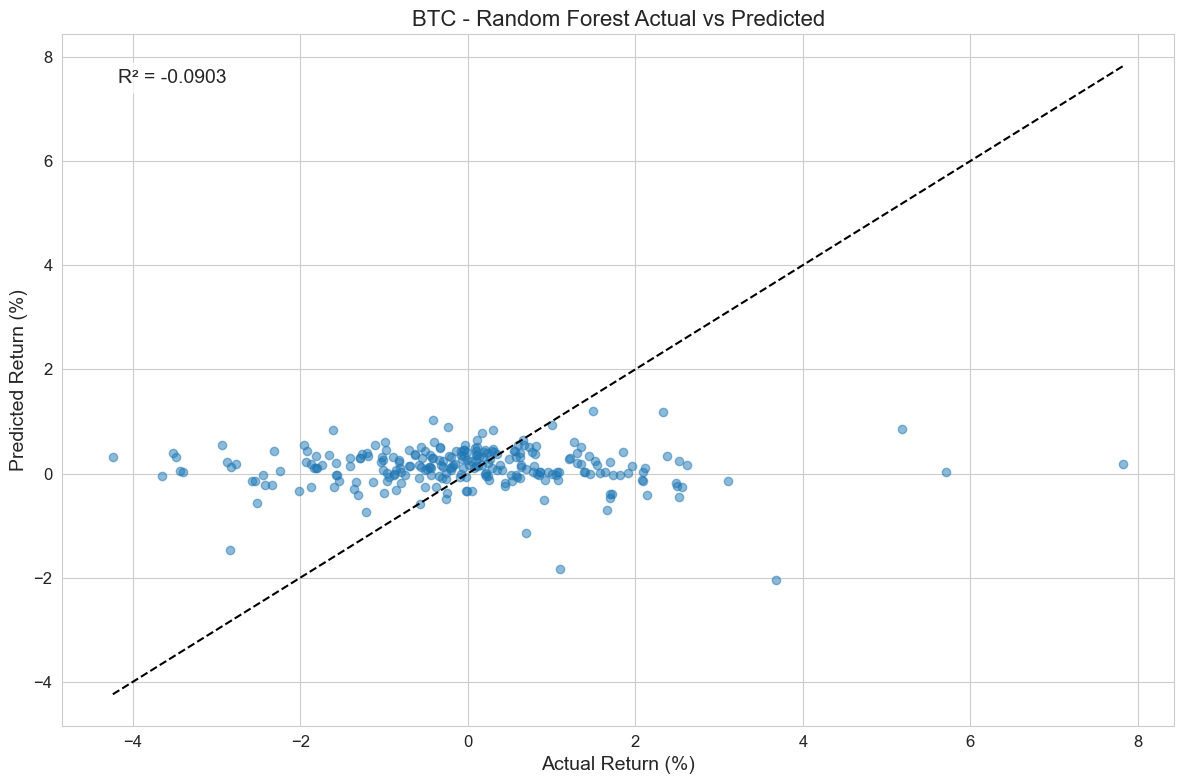

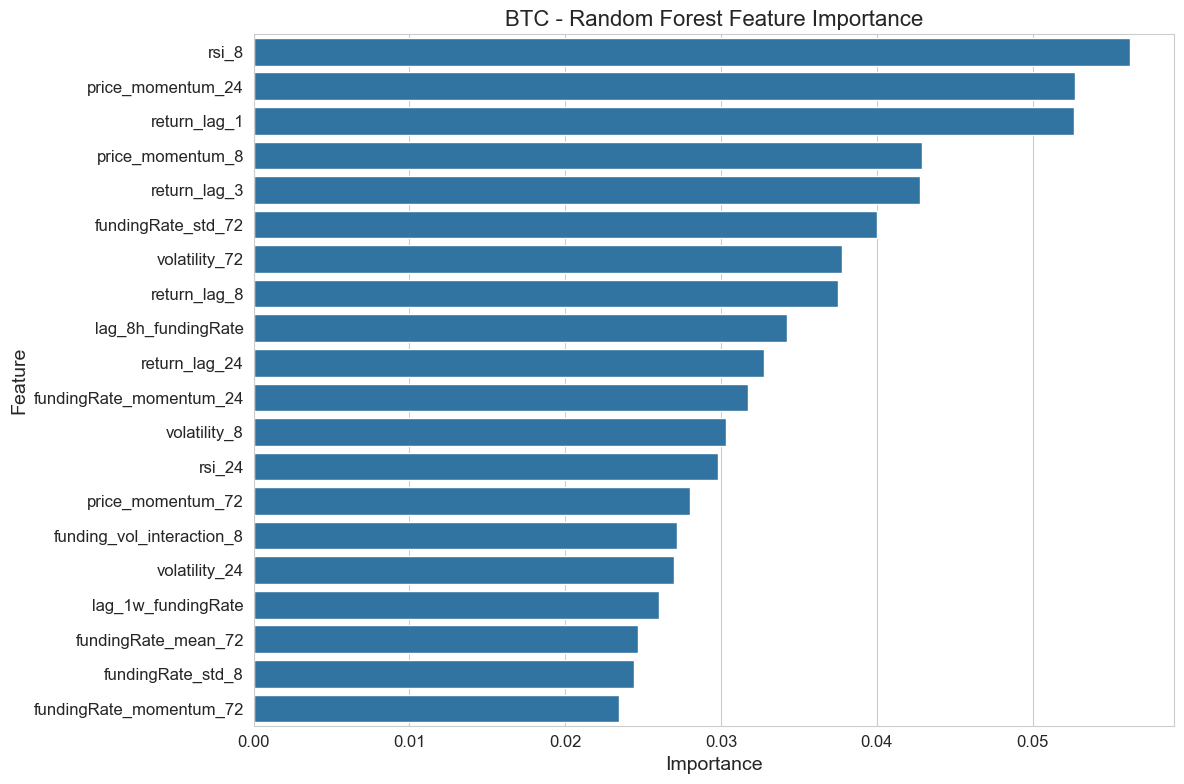

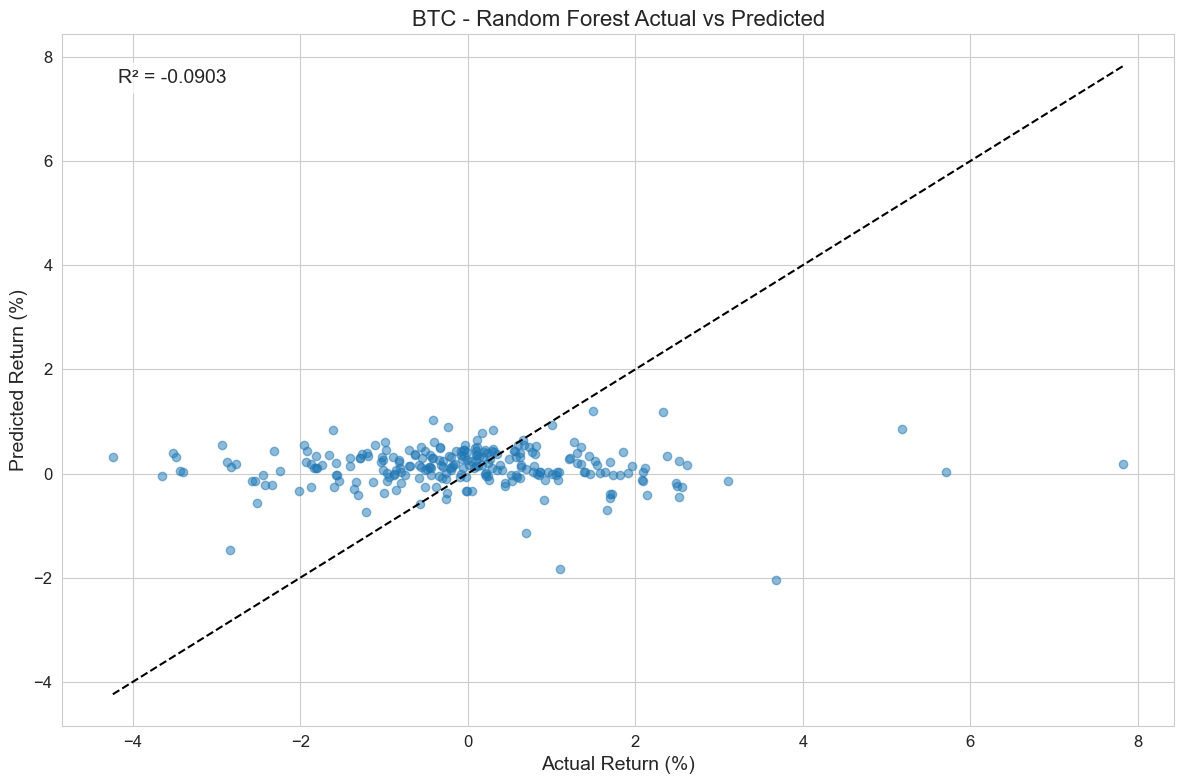

In [22]:
model_builder.plot_feature_importance('btc', 'Random Forest')
model_builder.plot_actual_vs_predicted('btc', 'Random Forest')

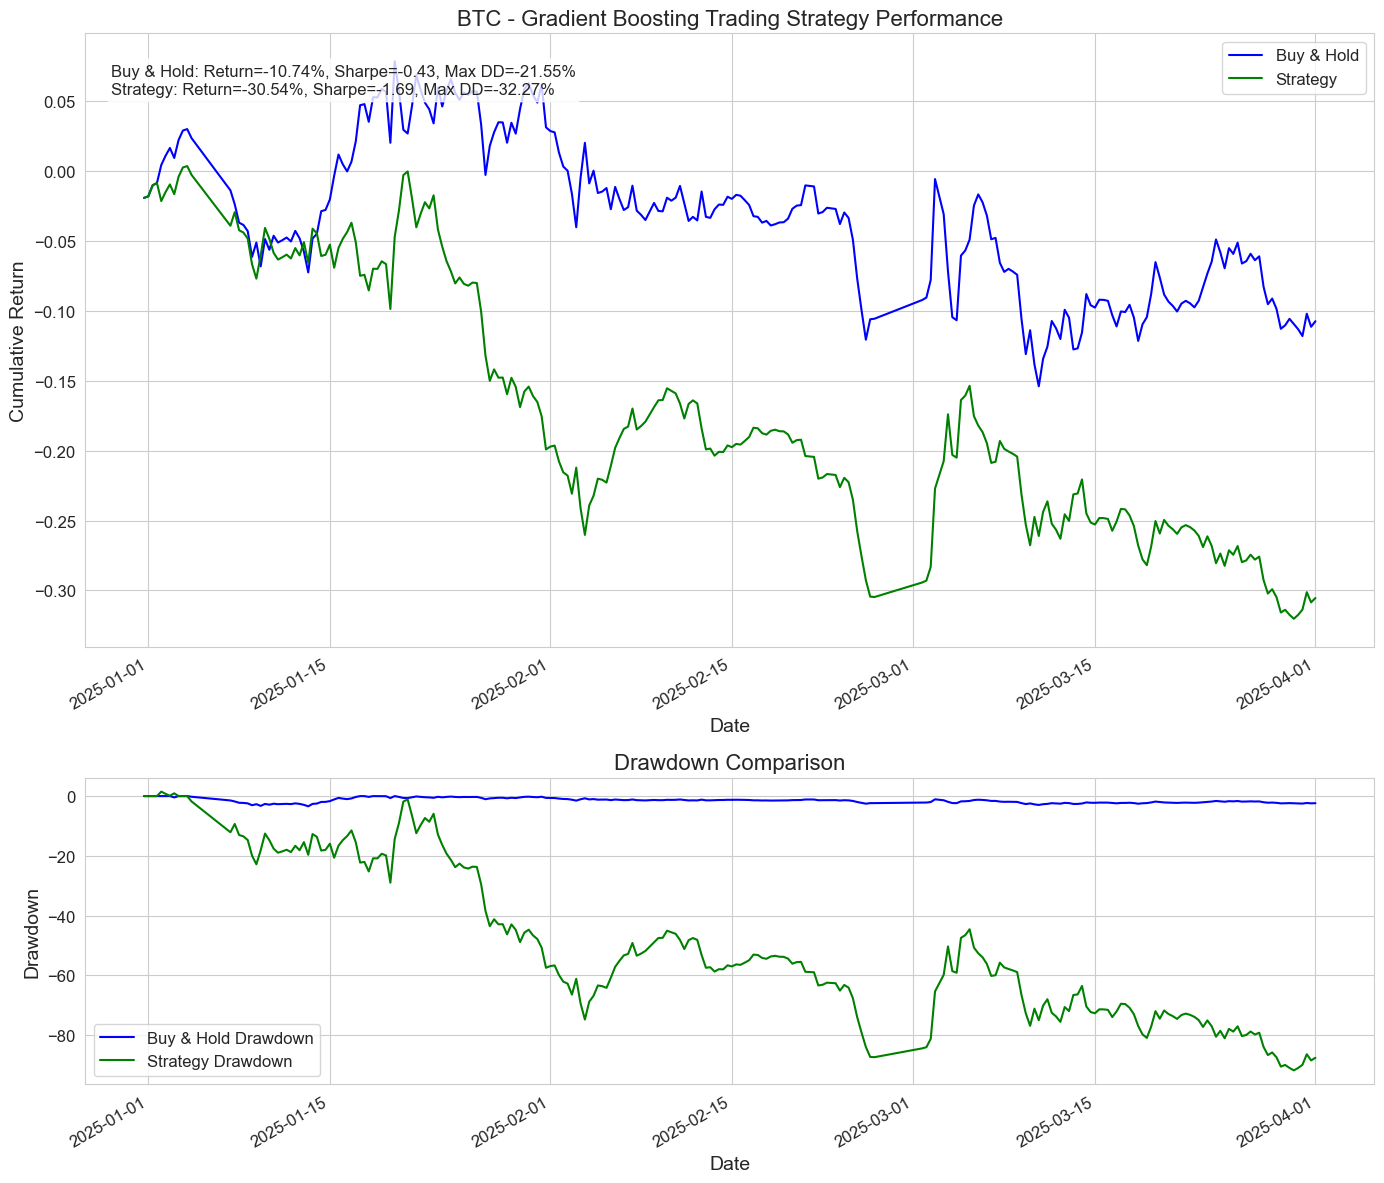

In [23]:
fig, perf = model_builder.backtest_trading_strategy('btc', 'Gradient Boosting')

In [24]:
cv_results = model_builder.perform_cross_validation('btc')

Cross-validating Linear Regression...
Linear Regression CV RMSE: 1.8246 (±0.4572)
Cross-validating Random Forest...
Random Forest CV RMSE: 1.6371 (±0.1750)
Cross-validating Gradient Boosting...
Gradient Boosting CV RMSE: 1.6733 (±0.2533)


Training data shape: (952, 37)
Test data shape: (239, 37)
Training Linear Regression...
Linear Regression Performance:
MSE: 6.5303
RMSE: 2.5555
MAE: 1.7526
R²: -0.0651
--------------------------------------------------
Training Random Forest...
Random Forest Performance:
MSE: 6.7503
RMSE: 2.5981
MAE: 1.7914
R²: -0.1009
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Performance:
MSE: 6.9163
RMSE: 2.6299
MAE: 1.8759
R²: -0.1280
--------------------------------------------------


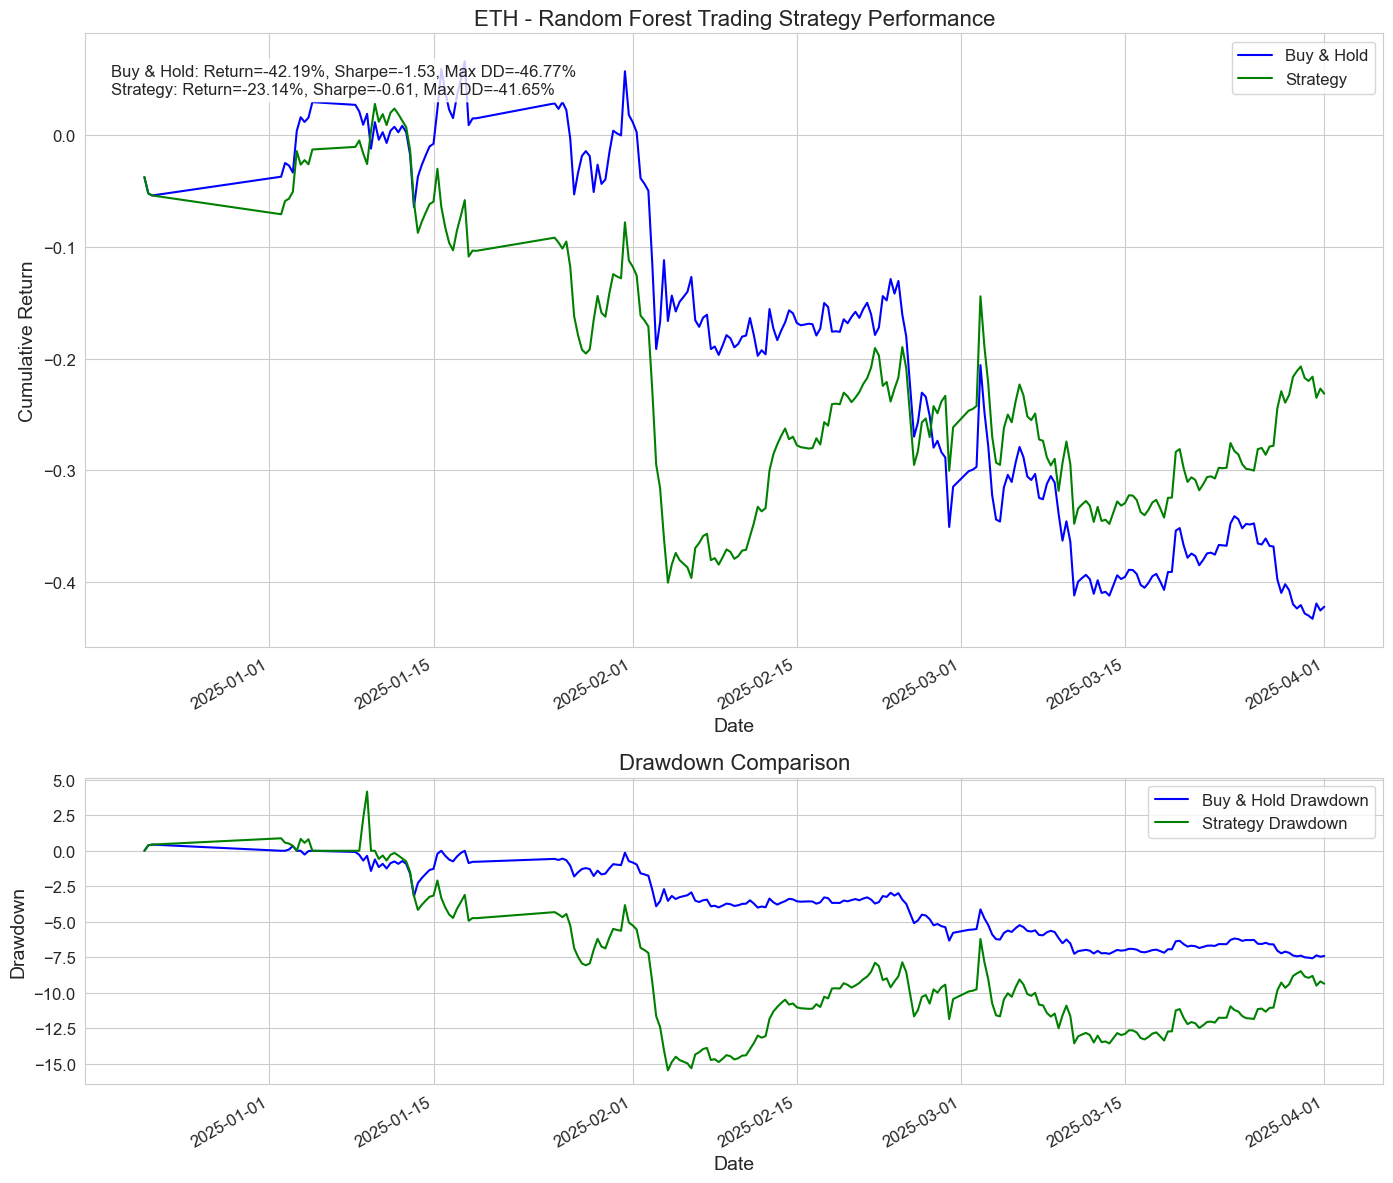

In [25]:
eth_results = model_builder.build_models('eth')
fig, perf = model_builder.backtest_trading_strategy('eth', 'Random Forest')


Processing BTC...
Training data shape: (1005, 37)
Test data shape: (252, 37)
Training Linear Regression...
Linear Regression Performance:
MSE: 2.4309
RMSE: 1.5591
MAE: 1.1436
R²: -0.0663
--------------------------------------------------
Training Random Forest...
Random Forest Performance:
MSE: 2.4856
RMSE: 1.5766
MAE: 1.1463
R²: -0.0903
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Performance:
MSE: 2.6060
RMSE: 1.6143
MAE: 1.1725
R²: -0.1431
--------------------------------------------------

Processing ETH...
Training data shape: (952, 37)
Test data shape: (239, 37)
Training Linear Regression...
Linear Regression Performance:
MSE: 6.5303
RMSE: 2.5555
MAE: 1.7526
R²: -0.0651
--------------------------------------------------
Training Random Forest...
Random Forest Performance:
MSE: 6.7503
RMSE: 2.5981
MAE: 1.7914
R²: -0.1009
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Performa

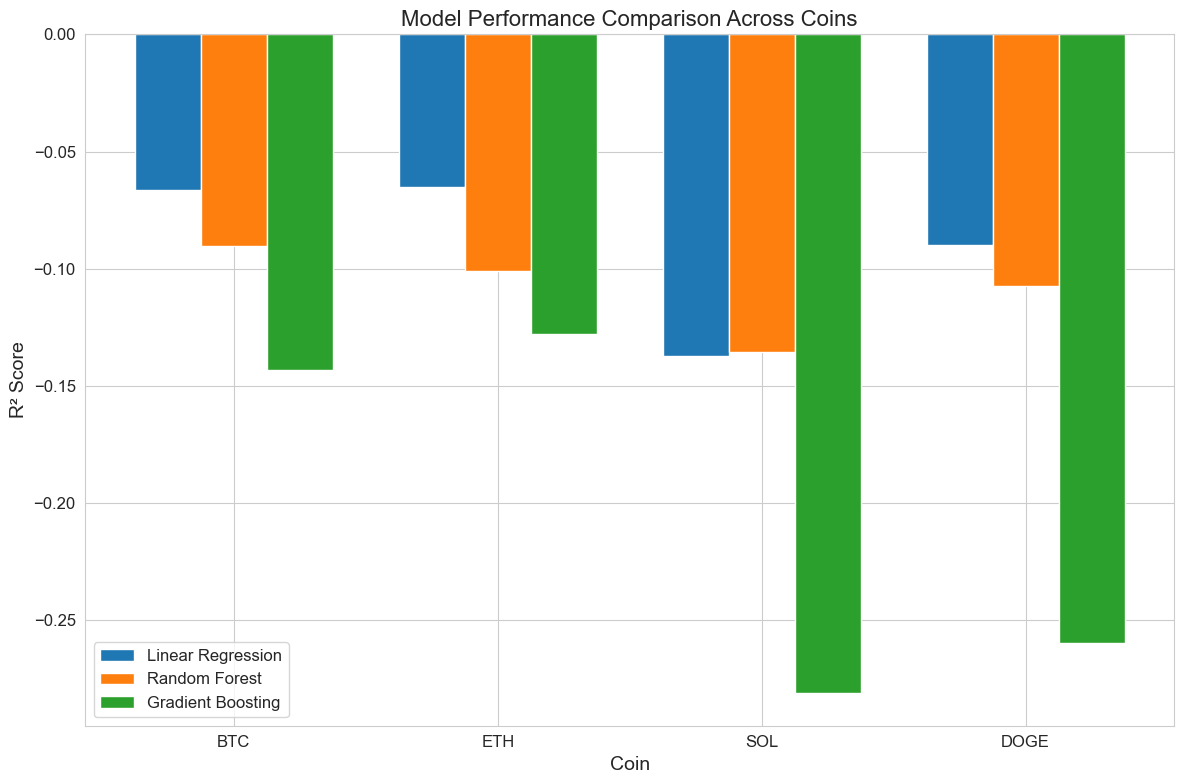

In [26]:
best_model_name = None
best_r2 = float('-inf')
summary = model_builder.generate_multi_coin_summary(['btc', 'eth', 'sol', 'doge'])

In [27]:
for model_name, df in summary.items():
    max_r2 = df['R2'].max()
    if max_r2 > best_r2:
        best_r2 = max_r2
        best_model_name = model_name

print(f"\nBest performing model overall: {best_model_name} with R² = {best_r2:.4f}")


Best performing model overall: Linear Regression with R² = -0.0651


## Understanding Negative R² Values

My analysis consistently produced negative R² values across all models and cryptocurrencies. This unusual statistical outcome warrants special explanation:

### Technical Interpretation
R² normally ranges from 0 to 1, with 1 indicating perfect prediction and 0 indicating performance no better than predicting the mean. Negative R² values occur when the model performs worse than simply predicting the mean value of the target variable.

### Implications for Funding Rate Signals
The negative R² values we observed (-0.06 to -0.14 for BTC) definitively demonstrate that:

1. **No Predictive Signal**: Funding rates contain no useful information for predicting short-term price movements in the way I modeled them.

2. **Adding Noise**: The models are actually learning patterns that decrease predictive performance compared to simply using the average historical return.

3. **Model Complexity Not Helping**: The fact that more complex models (Random Forest, Gradient Boosting) produced even more negative R² values suggests they're overfitting to noise rather than finding subtle signals.

This confirms that the negative R² values correctly indicated the models were worse than useless for trading purposes, as they systematically made incorrect predictions more often than correct ones.

## Conclusions

Several important conclusions:

1. **No Reliable Signal**: Despite the theoretical relationship between funding rates and market positioning, our modeling conclusively demonstrates that funding rates alone do not provide actionable predictive signals for short-term price movements.

2. **Model Complexity Not the Issue**: The consistent failure across linear and non-linear models suggests the problem is not model sophistication but rather the fundamental lack of predictive information in the funding rate data.